In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
# from scikeras.wrappers import KerasClassifier

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Convolution2D, Conv2D, MaxPooling2D, GlobalAveragePooling2D

2024-11-13 15:09:47.681602: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


#  Expolratory Data Analysis EDA on Heart Attack Dataset:

In [2]:
df = pd.read_csv(r'Medicaldataset.csv')

df.head(-1)

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,63,1,66,160,83,160.0,1.80,0.012,negative
1,20,1,94,98,46,296.0,6.75,1.060,positive
2,56,1,64,160,77,270.0,1.99,0.003,negative
3,66,1,70,120,55,270.0,13.87,0.122,positive
4,54,1,64,112,65,300.0,1.08,0.003,negative
...,...,...,...,...,...,...,...,...,...
1313,86,0,40,179,68,147.0,5.22,0.011,negative
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart rate                1319 non-null   int64  
 3   Systolic blood pressure   1319 non-null   int64  
 4   Diastolic blood pressure  1319 non-null   int64  
 5   Blood sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   object 
dtypes: float64(3), int64(5), object(1)
memory usage: 92.9+ KB


In [5]:
df.describe()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.193328,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.638173,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


In [6]:
df.isnull().sum()


Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64

In [7]:
df.nunique()

Age                          75
Gender                        2
Heart rate                   79
Systolic blood pressure     116
Diastolic blood pressure     73
Blood sugar                 244
CK-MB                       700
Troponin                    352
Result                        2
dtype: int64

In [8]:
df[df.duplicated()]

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result


In [9]:
heartattack_data = df.dropna() # no null values were found in the dataset
heartattack_data

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,63,1,66,160,83,160.0,1.80,0.012,negative
1,20,1,94,98,46,296.0,6.75,1.060,positive
2,56,1,64,160,77,270.0,1.99,0.003,negative
3,66,1,70,120,55,270.0,13.87,0.122,positive
4,54,1,64,112,65,300.0,1.08,0.003,negative
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive
1317,54,1,58,117,68,443.0,5.80,0.359,positive


In [77]:
# Check unique values in the 'Result' column
unique_values = heartattack_data['Result'].unique()
print("Unique values in 'Result' column:", unique_values)

mapping= { 'negative':0, 'positive':1}
heartattack_data['Result'] = heartattack_data['Result'].replace(mapping)


#renaming gender to male and female for our ease

gender_mapping = {0: 'Male', 1: 'Female'}
heartattack_data['Gender'] = heartattack_data['Gender'].replace(gender_mapping)
heartattack_data

Unique values in 'Result' column: [0 1]


,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result,CK-MB_normalized
0,63,Female,66,160,83,160.0,1.80,0.012,0,0.004935
1,20,Female,94,98,46,296.0,6.75,1.060,1,0.021453
2,56,Female,64,160,77,270.0,1.99,0.003,0,0.005569
3,66,Female,70,120,55,270.0,13.87,0.122,1,0.045212
4,54,Female,64,112,65,300.0,1.08,0.003,0,0.002533
...,...,...,...,...,...,...,...,...,...,...
1314,44,Female,94,122,67,204.0,1.63,0.006,0,0.004368
1315,66,Female,84,125,55,149.0,1.33,0.172,1,0.003367
1316,45,Female,85,168,104,96.0,1.24,4.250,1,0.003067
1317,54,Female,58,117,68,443.0,5.80,0.359,1,0.018283


In [78]:
from sklearn.preprocessing import MinMaxScaler
# **Initialize the MinMaxScaler**
scaler = MinMaxScaler()

# Reshape the 'CK-MB' column to a 2D array (required by MinMaxScaler)
CK_MB = heartattack_data['CK-MB'].values.reshape(-1, 1)

# Fit the scaler to the data and transform the data
ck_mb_normalized = scaler.fit_transform(CK_MB)

# Convert the normalized data back to a 1D array and assign it to the DataFrame
heartattack_data['CK-MB_normalized'] = ck_mb_normalized.flatten()
heartattack_data.head(20)


,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result,CK-MB_normalized
0,63,Female,66,160,83,160.0,1.800,0.012,0,0.004935
1,20,Female,94,98,46,296.0,6.750,1.060,1,0.021453
2,56,Female,64,160,77,270.0,1.990,0.003,0,0.005569
3,66,Female,70,120,55,270.0,13.870,0.122,1,0.045212
4,54,Female,64,112,65,300.0,1.080,0.003,0,0.002533
5,52,Male,61,112,58,87.0,1.830,0.004,0,0.005035
6,38,Male,40,179,68,102.0,0.710,0.003,0,0.001298
7,61,Female,60,214,82,87.0,300.000,2.370,1,1.000000
8,49,Male,60,154,81,135.0,2.350,0.004,0,0.006771
9,65,Female,61,160,95,100.0,2.840,0.011,0,0.008406


### Sorting the dataset w.r.t Age

In [79]:
heartattack_data.sort_values(by = "Age").head(10)

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result,CK-MB_normalized
899,14,Male,89,111,57,133.0,2.620,0.012,0,0.007672
1269,19,Female,68,116,74,99.0,0.606,0.003,0,0.000951
500,19,Male,70,117,76,91.0,36.240,0.025,1,0.119858
97,19,Male,62,114,69,240.0,300.000,0.004,1,1.000000
109,20,Female,60,156,60,103.0,5.220,1.840,1,0.016347
604,20,Female,78,109,69,294.0,3.100,0.008,0,0.009273
1,20,Female,94,98,46,296.0,6.750,1.060,1,0.021453
981,21,Female,97,150,78,98.0,10.750,0.602,1,0.034801
317,21,Male,62,76,55,111.0,3.110,0.003,0,0.009307
426,21,Female,85,138,98,257.0,9.900,0.003,1,0.031964


In [50]:



# Grouping

df_1 = heartattack_data.groupby('Gender')[['Age','Heart rate','Systolic blood pressure','Diastolic blood pressure','Blood sugar','CK-MB','Troponin','Result','CK-MB_normalized']].mean().sort_values(by = 'Age')
df_1



,Age,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result,CK-MB_normalized
Gender,,,,,,,,,
Female,55.277011,77.343678,127.378161,72.174713,146.993103,15.857391,0.415493,0.647126,0.051843
Male,57.968820,80.260579,126.768374,72.452116,145.939198,14.144497,0.255243,0.550111,0.046128


In [51]:
Female_heartattackdata = heartattack_data[heartattack_data['Gender'].str.contains('Female')][['Age','Heart rate','Systolic blood pressure',	'Diastolic blood pressure','Diastolic blood pressure','Blood sugar','CK-MB','Troponin','Result','CK-MB_normalized']].sort_values(by = 'Age').head(10)
Female_heartattackdata

,Age,Heart rate,Systolic blood pressure,Diastolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result,CK-MB_normalized
1269,19,68,116,74,74,99.0,0.606,0.003,0,0.000951
1,20,94,98,46,46,296.0,6.750,1.060,1,0.021453
109,20,60,156,60,60,103.0,5.220,1.840,1,0.016347
604,20,78,109,69,69,294.0,3.100,0.008,0,0.009273
981,21,97,150,78,78,98.0,10.750,0.602,1,0.034801
426,21,85,138,98,98,257.0,9.900,0.003,1,0.031964
428,21,85,204,84,84,93.0,2.710,0.002,0,0.007972
533,22,56,126,63,63,128.0,5.410,0.004,0,0.016982
615,22,84,160,79,79,102.0,2.250,0.006,0,0.006437
897,23,82,138,82,82,89.0,1.460,0.005,0,0.003801


In [52]:
Male_heartattackdata = heartattack_data[heartattack_data['Gender'].str.contains('Male')][['Age','Heart rate','Systolic blood pressure',	'Diastolic blood pressure','Blood sugar','CK-MB','Troponin','Result','CK-MB_normalized']].sort_values(by = 'Age').head(10)
Male_heartattackdata

,Age,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result,CK-MB_normalized
899,14,89,111,57,133.0,2.62,0.012,0,0.007672
97,19,62,114,69,240.0,300.00,0.004,1,1.000000
500,19,70,117,76,91.0,36.24,0.025,1,0.119858
317,21,62,76,55,111.0,3.11,0.003,0,0.009307
517,22,63,170,104,143.0,1.97,0.006,0,0.005503
747,24,60,144,54,136.0,4.60,0.003,0,0.014279
887,25,62,76,55,104.0,1.12,0.003,0,0.002666
1128,26,88,110,70,102.0,3.21,0.006,0,0.009640
1089,27,93,119,63,137.0,6.74,0.003,1,0.021420
665,27,61,112,58,112.0,2.25,0.003,0,0.006437


In [53]:
import plotly.offline as py
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import plotly.express as px

def attack_ratio(data):
    """
    Make a pie chart of 'Result' values
    Results: 0 = Negative, 1 = Positive
    """
    
    Result = data['Result'].value_counts()
    values = [Result[1], Result[0]]
    labels = ['Positive','Negative']
    colors = ['3A0CA3', 'ba181b']
    
    fig_pie = go.Pie(labels=labels, values=values,
                     marker={'colors': colors, 
                             'line': {'color': 'White', 'width': 2}})
    layout = go.Layout(height=500, width=500, title={'text': 'Heart Attack Ratio Proportion'})  # Set the height and width
    fig = go.Figure(data=[fig_pie], layout=layout)
    py.iplot(fig)
    return py
    
    
attack_ratio(heartattack_data)

<module 'plotly.offline' from '/home/usama/.local/lib/python3.8/site-packages/plotly/offline/__init__.py'>

Most of the cases diagnosed are likely to have a heart attack , more than 60 %. While less than 40 % cases are negative.

In [54]:
# Count the occurrences of each value in the 'Result' column
result_counts = heartattack_data['Result'].value_counts()

print(result_counts)


1    810
0    509
Name: Result, dtype: int64


In [62]:


def gender_ratio(data):
    """
    Make a pie chart of 'Gender' values
    Gender: 1 = Female, 0 = Male
    """
    # Pie chart of Gender ratio
    Result = data['Gender'].value_counts()
    print(Result[0])
    total_count = Result.sum()
    values = {'Female': Result[1] / total_count, 'Male': Result[0] / total_count}
    
    fig_pie = px.pie(values=values,
                     names=values.keys(),
                     height=500, width=500, 
                     hole=0.7,
                     color_discrete_sequence = ['#4c78a8', '#72b7b2']
                     )
    fig_pie.update_layout(plot_bgcolor='#fafafa', paper_bgcolor='#fafafa',
                            title={'text': 'Ratio of Heart Attack in Males and Females'})   
    
    return fig_pie


fig_pie = gender_ratio(heartattack_data)
fig_pie.show()

870


The number of Male population are two times of Female population.

In [63]:
gender_counts = heartattack_data['Gender'].value_counts()

print(gender_counts)

Female    870
Male      449
Name: Gender, dtype: int64


Result    0    1
Gender          
Female  307  563
Male    202  247


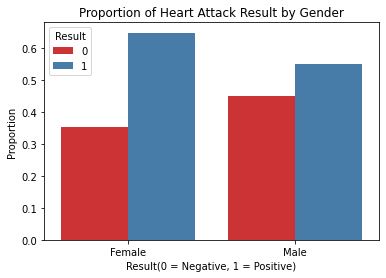

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

def attack_proportion_gender(data):
    """
    Plot a bar chart of the proportion of Result vs. Gender.
    Show the percentage of positive heart attack Result for each gender.
    """
    # Calculate the proportion of positive results by gender
    gender_result_counts = data.groupby(['Gender', 'Result']).size().unstack(fill_value=0)
    print(gender_result_counts )
    #print(heartattack_data['Gender'] )
    gender_proportions = (gender_result_counts.div(gender_result_counts.sum(axis=1), axis=0)).reset_index().melt(id_vars='Gender', value_name='proportion')

    # Plotting
    sns.barplot(data=gender_proportions, x='Gender', y='proportion', hue='Result', palette='Set1')
    plt.title('Proportion of Heart Attack Result by Gender')
    plt.xlabel('Result(0 = Negative, 1 = Positive)')
    plt.ylabel('Proportion')
    plt.show()


# Replace `heartattackeda` with your actual dataset
attack_proportion_gender(heartattack_data)


In [65]:
# Assuming 'Gender' column exists and contains 'Male' and 'Female'
# If the gender information is in another column, replace 'Gender' with the correct column name.

gender_counts = heartattack_data['Gender'].value_counts()

print(gender_counts)


Female    870
Male      449
Name: Gender, dtype: int64


In [66]:
# Group by 'Gender' and 'Result', then count occurrences
result_gender_counts = heartattack_data.groupby(['Gender', 'Result']).size().unstack(fill_value=0)

print(result_gender_counts)


Result    0    1
Gender          
Female  307  563
Male    202  247


In [83]:
import plotly.express as px

def female_positive_ratio(data):
    """
    Make a pie chart of 'Result' values for females.
    Results: 0 = Negative (No Heart Attack), 1 = Positive (Heart Attack)
    """
    # Calculate the count of each Result category
    results = data['Result'].value_counts()
    print(results)
    total_count = results.sum()

    # Set values for 'Positive' (1) and 'Negative' (0) results
    values = {
        'Negative': results.get(0, 0) / total_count,  # No Heart Attack cases
        'Positive': results.get(1, 0) / total_count   # Heart Attack cases
    }
    
    # Create the pie chart
    fig_pie = px.pie(
        values=values.values(),
        names=values.keys(),
        height=500, width=500, 
        hole=0.7,
        color_discrete_sequence=['#E500A4', '#fdc5f5']  # Different colors for better distinction
    )
    
    # Customize layout
    fig_pie.update_layout(
        plot_bgcolor='#fafafa',
        paper_bgcolor='#fafafa',
        title={'text': 'Female Heart Attack Results'}
    )
    
    return fig_pie

# Assuming Female_heartattackdata is already filtered to include only female data
fig_pie = female_positive_ratio(Female_heartattackdata)
fig_pie.show()


0    6
1    4
Name: Result, dtype: int64


In [89]:
import plotly.express as px

def female_positive_ratio(data):
    """
    Make a pie chart of 'Result' values for female gender.
    Results: 0 = Negative, 1 = Positive
    """
    
    # Filter data for females (assuming 'Female' represents the female gender)
    female_data = data[data['Gender'] == 'Female']
    
    # Get counts of positive and negative results for females
    results = female_data['Result'].value_counts()
    print(results)
    print(results[1]) #for positive
    # Calculate the proportion of negative and positive results
    total_count = results.sum()
    values = {'Negative': results.get(0, 0) / total_count, 'Positive': results.get(1, 0) / total_count}
    
    # Create a pie chart using Plotly Express
    fig_pie = px.pie(values=values,
                     names=values.keys(),
                     height=500, width=500, 
                     hole=0.7,
                     color_discrete_sequence=['#E500A4', '#fdc5f5'])
    
    # Update layout for better visualization
    fig_pie.update_layout(
        plot_bgcolor='#fafafa', 
        paper_bgcolor='#fafafa',
        title={'text': 'Female Heart Attack Results'}
    )
    
    return fig_pie

# Example usage
fig_pie = female_positive_ratio(heartattack_data)
if fig_pie:
    fig_pie.show()


1    563
0    307
Name: Result, dtype: int64
563


In [91]:
import plotly.express as px

def male_positive_ratio(data):
    """
    Make a pie chart of 'Result' values for female gender.
    Results: 0 = Negative, 1 = Positive
    """
    
    # Filter data for females (assuming 'Female' represents the female gender)
    male_data = data[data['Gender'] == 'Male']
    
    # Get counts of positive and negative results for females
    results = male_data['Result'].value_counts()
    print(results)
    # Calculate the proportion of negative and positive results
    total_count = results.sum()
    values = {'Negative': results.get(0, 0) / total_count, 'Positive': results.get(1, 0) / total_count}
    
    # Create a pie chart using Plotly Express
    fig_pie = px.pie(values=values,
                     names=values.keys(),
                     height=500, width=500, 
                     hole=0.7,
                     color_discrete_sequence=['#4895ef', '#3f37c9'])
    
    # Update layout for better visualization
    fig_pie.update_layout(
        plot_bgcolor='#fafafa', 
        paper_bgcolor='#fafafa',
        title={'text': 'Male Heart Attack Results'}
    )
    
    return fig_pie

# Example usage
fig_pie = male_positive_ratio(heartattack_data)
if fig_pie:
    fig_pie.show()


1    247
0    202
Name: Result, dtype: int64


/home/usama/.local/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.

/home/usama/.local/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.

/home/usama/.local/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning:

Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.

/home/usama/.local/lib/python3.8/site-packages/seaborn/_decorato

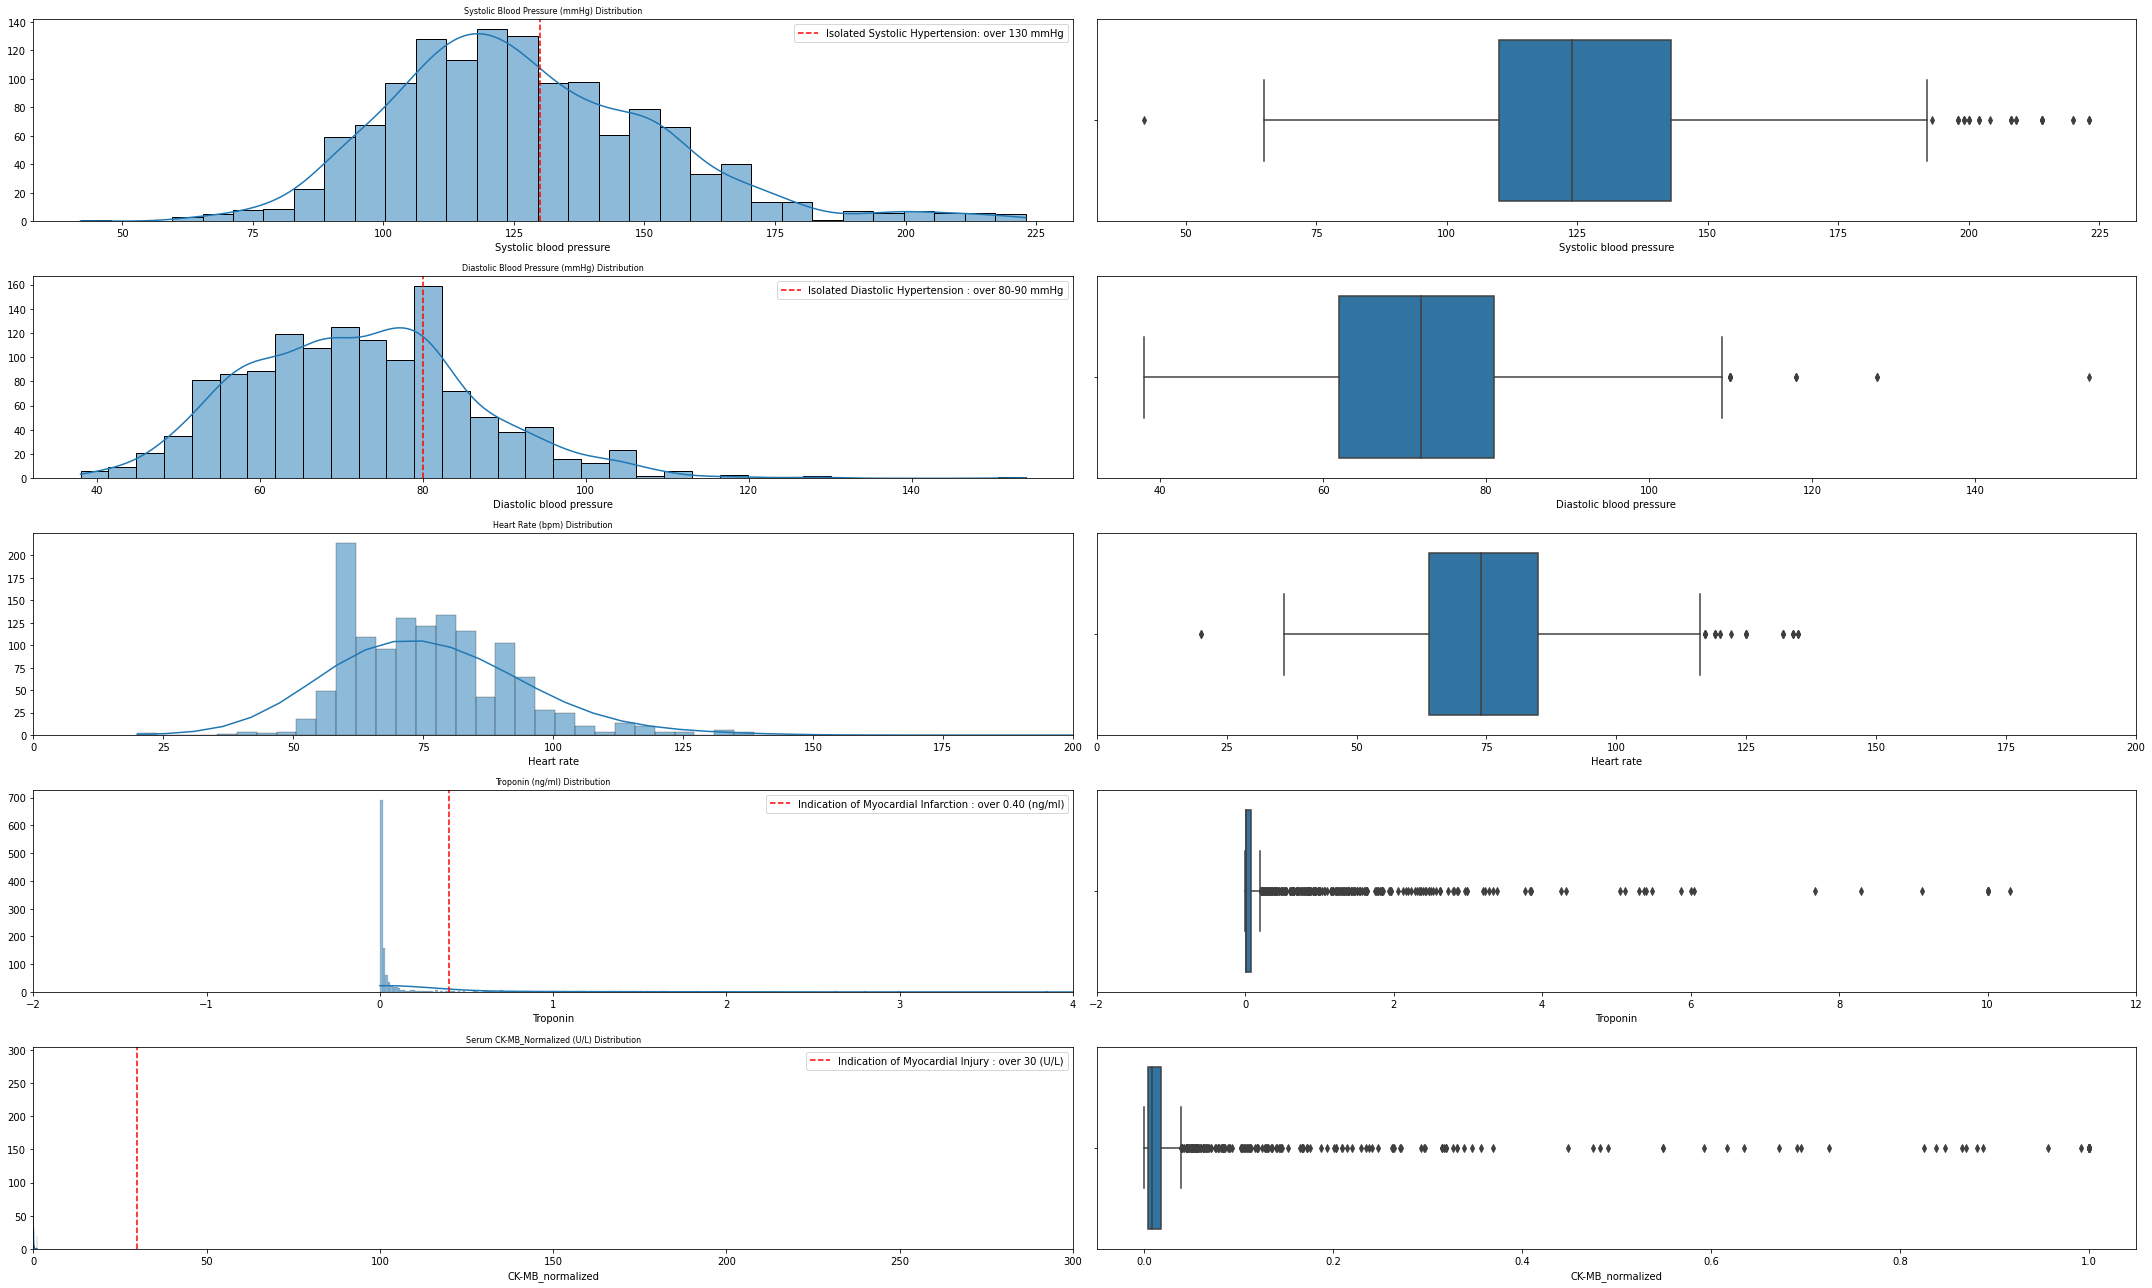

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

def risk_factors_dist(data):
    # Set up the figure for the subplots
    fig = plt.figure(figsize=(30, 18))

    # Resting Systolic Blood Pressure
    plt.subplot(5, 2, 1)
    sns.histplot(data['Systolic blood pressure'], kde=True)
    plt.title('Systolic Blood Pressure (mmHg) Distribution', fontsize=8)
    plt.axvline(x=130, color='r', linestyle='--', label='Isolated Systolic Hypertension: over 130 mmHg')
    plt.ylabel('')
    plt.legend()

    plt.subplot(5, 2, 2)
    sns.boxplot(data['Systolic blood pressure'], orient='h')

    # Serum Diastolic Blood Pressure
    plt.subplot(5, 2, 3)
    sns.histplot(data['Diastolic blood pressure'], kde=True)
    plt.title('Diastolic Blood Pressure (mmHg) Distribution', fontsize=8)
    plt.axvline(x=80, color='r', linestyle='--', label='Isolated Diastolic Hypertension : over 80-90 mmHg')
    plt.ylabel('')
    plt.legend()

    plt.subplot(5, 2, 4)
    sns.boxplot(data['Diastolic blood pressure'], orient='h')

    # Maximum Heart Rate
    plt.subplot(5, 2, 5)
    sns.histplot(data['Heart rate'], kde=True)
    plt.title('Heart Rate (bpm) Distribution', fontsize=8)
    plt.ylabel('')
    plt.xlim(0, 200)  # Set x-axis limits to 0-200

    plt.subplot(5, 2, 6)
    sns.boxplot(data['Heart rate'], orient='h')
    plt.xlim(0, 200)  # Set x-axis limits to 0-200

    # Troponin Levels
    plt.subplot(5, 2, 7)
    sns.histplot(data['Troponin'], kde=True)
    plt.title('Troponin (ng/ml) Distribution', fontsize=8)
    plt.axvline(x=0.40, color='r', linestyle='--', label='Indication of Myocardial Infarction : over 0.40 (ng/ml)')
    plt.xlim(-2, 4)
    plt.ylabel('')
    plt.legend()

    plt.subplot(5, 2, 8)
    sns.boxplot(data['Troponin'], orient='h')
    plt.xlim(-2, 12)

    # Serum CK-MB normalized levels
    plt.subplot(5, 2, 9)
    sns.histplot(data['CK-MB_normalized'], kde=True)
    plt.title('Serum CK-MB_Normalized (U/L) Distribution', fontsize=8)
    plt.axvline(x=30, color='r', linestyle='--', label='Indication of Myocardial Injury : over 30 (U/L)')
    plt.xlim(0, 300)
    plt.ylabel('')
    plt.legend()

    plt.subplot(5, 2, 10)
    sns.boxplot(data['CK-MB_normalized'], orient='h')

    # Adjust the layout
    plt.tight_layout()
    plt.show()

# Example usage
risk_factors_dist(heartattack_data)


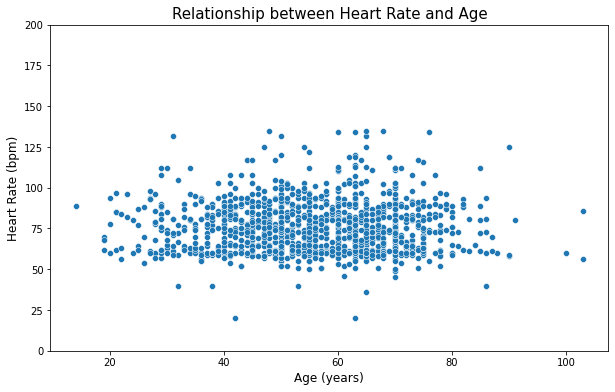

In [93]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Heart rate', data=heartattack_data)
plt.title('Relationship between Heart Rate and Age', fontsize=15)
plt.ylim(0, 200)  # Set x-axis limits to 0-200
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Heart Rate (bpm)', fontsize=12)
plt.show()

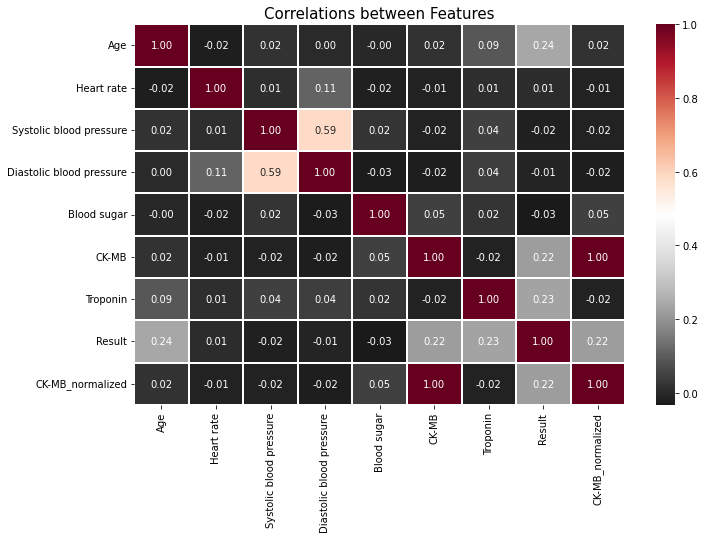

In [94]:
import numpy as np

def correlation_heatmap(data):
    """
    Correlation Heat Map of the features.
    """
    numerical_data = data.select_dtypes(include=[np.number])
    plt.figure(figsize=(11, 7))
    sns.heatmap(numerical_data.corr(), annot=True, linewidth=0.2, 
                fmt='.2f', cmap='RdGy_r')
    plt.title('Correlations between Features', fontsize=15)
    plt.show()
    
    
correlation_heatmap(heartattack_data)

In [95]:
heartattack_data

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result,CK-MB_normalized
0,63,Female,66,160,83,160.0,1.80,0.012,0,0.004935
1,20,Female,94,98,46,296.0,6.75,1.060,1,0.021453
2,56,Female,64,160,77,270.0,1.99,0.003,0,0.005569
3,66,Female,70,120,55,270.0,13.87,0.122,1,0.045212
4,54,Female,64,112,65,300.0,1.08,0.003,0,0.002533
...,...,...,...,...,...,...,...,...,...,...
1314,44,Female,94,122,67,204.0,1.63,0.006,0,0.004368
1315,66,Female,84,125,55,149.0,1.33,0.172,1,0.003367
1316,45,Female,85,168,104,96.0,1.24,4.250,1,0.003067
1317,54,Female,58,117,68,443.0,5.80,0.359,1,0.018283


In [96]:
heartattack_data = heartattack_data.drop(columns='CK-MB')

In [97]:
x= heartattack_data.drop(columns=['Result'])  
y = heartattack_data['Result'] 

In [98]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size =0.3)

# Random Forest Model 

In [99]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Encode Gender: Male as 0, Female as 1
x_train['Gender'] = x_train['Gender'].replace({'Male': 0, 'Female': 1})
x_test['Gender'] = x_test['Gender'].replace({'Male': 0, 'Female': 1})

# Initialize and fit the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(x_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(x_test)

# Calculate and print accuracy, classification report, and confusion matrix
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Test Accuracy: 98.48%
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       159
           1       0.99      0.99      0.99       237

    accuracy                           0.98       396
   macro avg       0.98      0.98      0.98       396
weighted avg       0.98      0.98      0.98       396

Confusion Matrix:
 [[156   3]
 [  3 234]]


In [100]:
# Get feature importance scores
importances = rf_model.feature_importances_

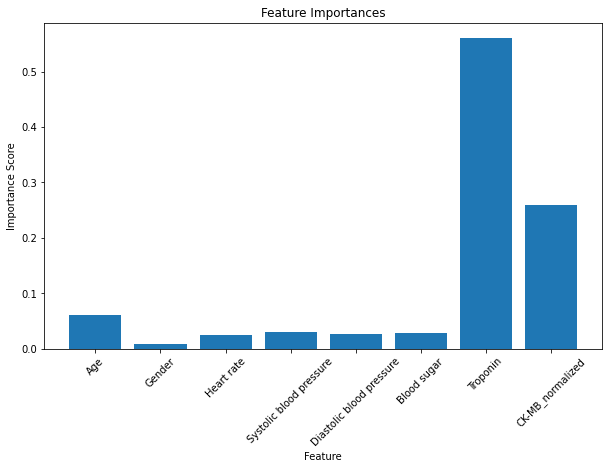

In [101]:
# Plot feature importances
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(x_train.columns, importances)
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

Test Accuracy: 98.48%
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       159
           1       0.99      0.99      0.99       237

    accuracy                           0.98       396
   macro avg       0.98      0.98      0.98       396
weighted avg       0.98      0.98      0.98       396

Confusion Matrix:
 [[156   3]
 [  3 234]]


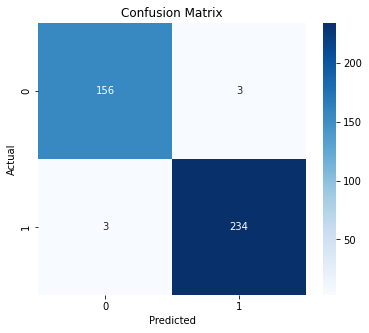

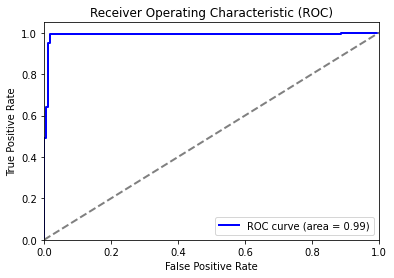

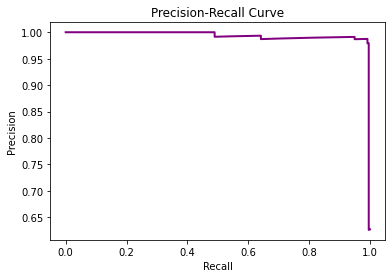

F1 Score: 0.99
R² Score: 0.94


In [104]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score, r2_score,
    precision_recall_curve, roc_curve, auc
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

from sklearn.preprocessing import LabelEncoder

# Encode labels as 0 and 1
le = LabelEncoder()
y_test_binary = le.fit_transform(y_test)
y_pred_binary = le.transform(y_pred)


# Train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(x_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(x_test)
y_pred_proba = rf_model.predict_proba(x_test)[:, 1]

# Calculate various scores
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test_binary, y_pred_binary)
r2 = r2_score(y_test_binary, y_pred_binary)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", conf_matrix)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test_binary, y_pred_proba)
plt.figure()
plt.plot(recall, precision, color='purple', lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

# Display F1 and R² scores
print(f"F1 Score: {f1:.2f}")
print(f"R² Score: {r2:.2f}")


In [107]:
import pandas as pd

# Create sample patient data for prediction
patient_data = pd.DataFrame({
    'Age': [30],
    'Gender': [1],  # 1 for Male, 0 for Female
    'Heart rate': [78],
    'Systolic blood pressure': [125],
    'Diastolic blood pressure': [87],
    'Blood sugar': [110.0],
#     'CK-MB': [5.5],
    'Troponin': [0.010],
 'CK-MB_normalized': [0.018]
})

# Ensure all columns in patient_data match those used to train the model
# Make predictions using the trained model
prediction = rf_model.predict(patient_data)

# Output the prediction result
if prediction[0] == 1:
    print("The patient is likely to have a heart attack.")
else:
    print("The patient is not likely to have a heart attack.")


The patient is not likely to have a heart attack.


In [109]:
import pandas as pd

# Assuming 'df' is your existing DataFrame containing the data
# Replace this with the actual loading method if necessary (e.g., pd.read_csv(), pd.read_excel(), etc.)
# df = pd.read_csv('your_data.csv')

# Get the min and max CK-MB values from the DataFrame
ck_mb_min = df['CK-MB'].min()
ck_mb_max = df['CK-MB'].max()

# Take CK-MB input from the user
ck_mb_input = float(input("Enter CK-MB value: "))  # Input CK-MB value as float

# Normalize the CK-MB value using min-max normalization
ck_mb_normalized = (ck_mb_input - ck_mb_min) / (ck_mb_max - ck_mb_min)

# Prepare the patient data with the normalized CK-MB value
patient_data = pd.DataFrame({
    'Age': [20],  # Example age, can be modified as per user input
    'Gender': [1],  # 1 for Male, 0 for Female
    'Heart rate': [78],  # Example heart rate
    'Systolic blood pressure': [125],  # Example systolic BP
    'Diastolic blood pressure': [87],  # Example diastolic BP
    'Blood sugar': [110.0],  # Example blood sugar
    #'CK-MB': [ck_mb_normalized],  # Original CK-MB value entered by user
    'Troponin': [0.010],  # Example Troponin value
    'CK-MB_normalized': [ck_mb_normalized]  # Normalized CK-MB value
})

# Output the normalized CK-MB and the patient data for prediction
print(f"Normalized CK-MB: {ck_mb_normalized}")
print("Patient Data for Prediction:")
print(patient_data)

# Example prediction (replace 'best_rf' with your actual trained model)
prediction = rf_model.predict(patient_data)
if prediction[0] == 1:
    print("The patient is likely to have a heart attack.")
else:
    print("The patient is not likely to have a heart attack.")


Enter CK-MB value: 5.5
Normalized CK-MB: 0.017281824885961316
Patient Data for Prediction:
   Age  Gender  Heart rate  Systolic blood pressure  Diastolic blood pressure  \
0   20       1          78                      125                        87   

   Blood sugar  Troponin  CK-MB_normalized  
0        110.0      0.01          0.017282  
The patient is not likely to have a heart attack.
